# TorchSpin — GPU Acceleration & Automatic Differentiation

TorchSpin leverages PyTorch to provide two key capabilities beyond traditional EPR simulation:

1. **GPU acceleration** — Run `pepper` on CUDA for large orientation grids
2. **Automatic differentiation** — Compute $\partial \text{spectrum} / \partial \theta$ for any spin parameter $\theta$

This notebook demonstrates both features using `differentiable_spectrum` and `pepper` with `Options(device='cuda')`.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import time
from torchspin import (
    SpinSystem, Experiment, Options,
    pepper, differentiable_spectrum,
)

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch: 2.5.1+cu121
CUDA available: True
GPU: NVIDIA GeForce RTX 4090


## 1. GPU-Accelerated Powder Simulation

Pass `device='cuda'` in `Options` to run the full orientation grid on GPU. This is most beneficial for large grid sizes and complex spin systems.

In [2]:
# Define a Cu(II) system — complex enough to benefit from GPU
cu_sys = SpinSystem(
    S=[0.5],
    g=[[2.055, 2.055, 2.225]],
    Nucs=['63Cu', '14N'],
    A=[[40.0, 40.0, 490.0], [14.0, 14.0, 14.0]],
    lw=[0.8, 0.0],
)
exp = Experiment(mwFreq=9.5, Range=[270, 380], nPoints=2048, Harmonic=1)
grid_size = 50

# --- CPU ---
opt_cpu = Options(GridSize=grid_size, Verbosity=0, device='cpu')
t0 = time.perf_counter()
B_cpu, spec_cpu = pepper(cu_sys, exp, opt_cpu)
t_cpu = time.perf_counter() - t0
print(f"CPU time: {t_cpu:.3f} s")

# --- GPU ---
if torch.cuda.is_available():
    opt_gpu = Options(GridSize=grid_size, Verbosity=0, device='cuda')
    # Warm-up run (CUDA kernel compilation)
    _ = pepper(cu_sys, exp, opt_gpu)
    torch.cuda.synchronize()

    t0 = time.perf_counter()
    B_gpu, spec_gpu = pepper(cu_sys, exp, opt_gpu)
    torch.cuda.synchronize()
    t_gpu = time.perf_counter() - t0
    print(f"GPU time: {t_gpu:.3f} s")
    print(f"Speedup:  {t_cpu / t_gpu:.1f}×")

CPU time: 0.111 s


GPU time: 0.083 s
Speedup:  1.3×


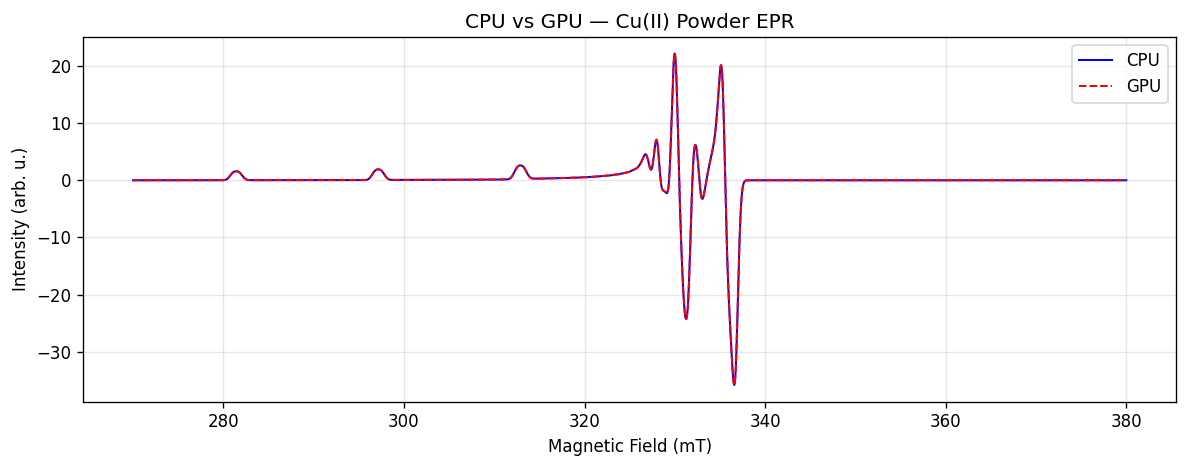

In [3]:
# Verify CPU and GPU produce identical spectra
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(B_cpu.numpy(), spec_cpu.numpy(), 'b', lw=1.2, label='CPU')
if torch.cuda.is_available():
    ax.plot(B_gpu.cpu().numpy(), spec_gpu.cpu().numpy(), 'r--', lw=1.2, label='GPU')
ax.set_xlabel('Magnetic Field (mT)')
ax.set_ylabel('Intensity (arb. u.)')
ax.set_title('CPU vs GPU — Cu(II) Powder EPR')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Differentiable Spectra with `differentiable_spectrum`

`differentiable_spectrum` provides a simplified interface that wraps `pepper` and keeps the full computation graph intact for PyTorch autograd. This lets you compute **gradients of the spectrum with respect to any spin parameter**.

Spectrum shape: torch.Size([512])
Requires grad: True


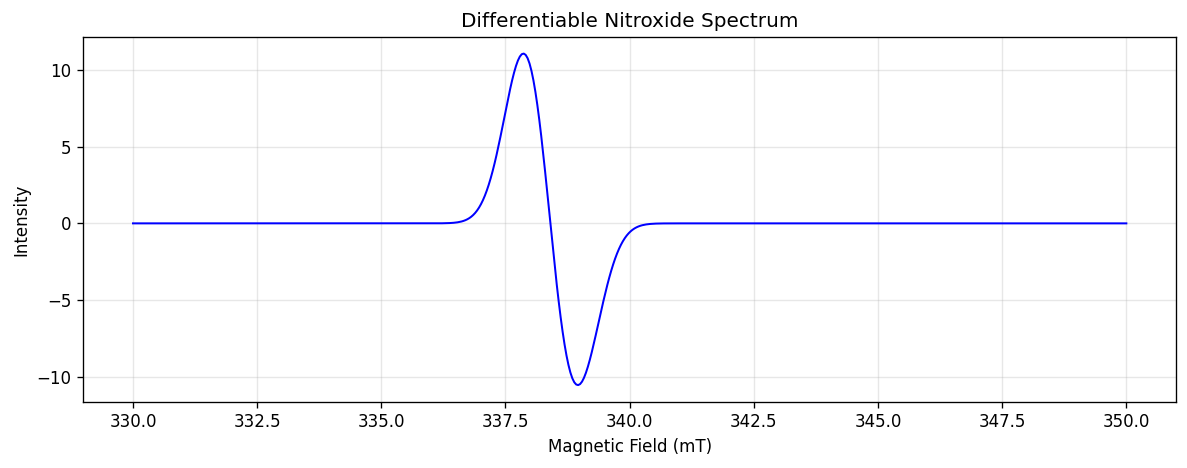

In [4]:
# g-tensor as a trainable parameter (requires_grad=True)
g = torch.tensor([2.009, 2.006, 2.002], dtype=torch.float64, requires_grad=True)

B, spec = differentiable_spectrum(
    g=g,
    lw_mT=1.0,
    mwFreq_GHz=9.5,
    B_range=(330, 350),
    nPoints=512,
    Harmonic=1,
    GridSize=31,
)

print(f"Spectrum shape: {spec.shape}")
print(f"Requires grad: {spec.requires_grad}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(B.detach().numpy(), spec.detach().numpy(), 'b', lw=1.2)
ax.set_xlabel('Magnetic Field (mT)')
ax.set_ylabel('Intensity')
ax.set_title('Differentiable Nitroxide Spectrum')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Computing Gradients — $\partial \text{spectrum} / \partial g$

Backpropagate through the simulation to get the **Jacobian** of the spectrum with respect to each $g$-value. This reveals how sensitive each spectral point is to each parameter.

∂L/∂g = tensor([-583892.1914,  -45237.3053,  633401.2355], dtype=torch.float64)


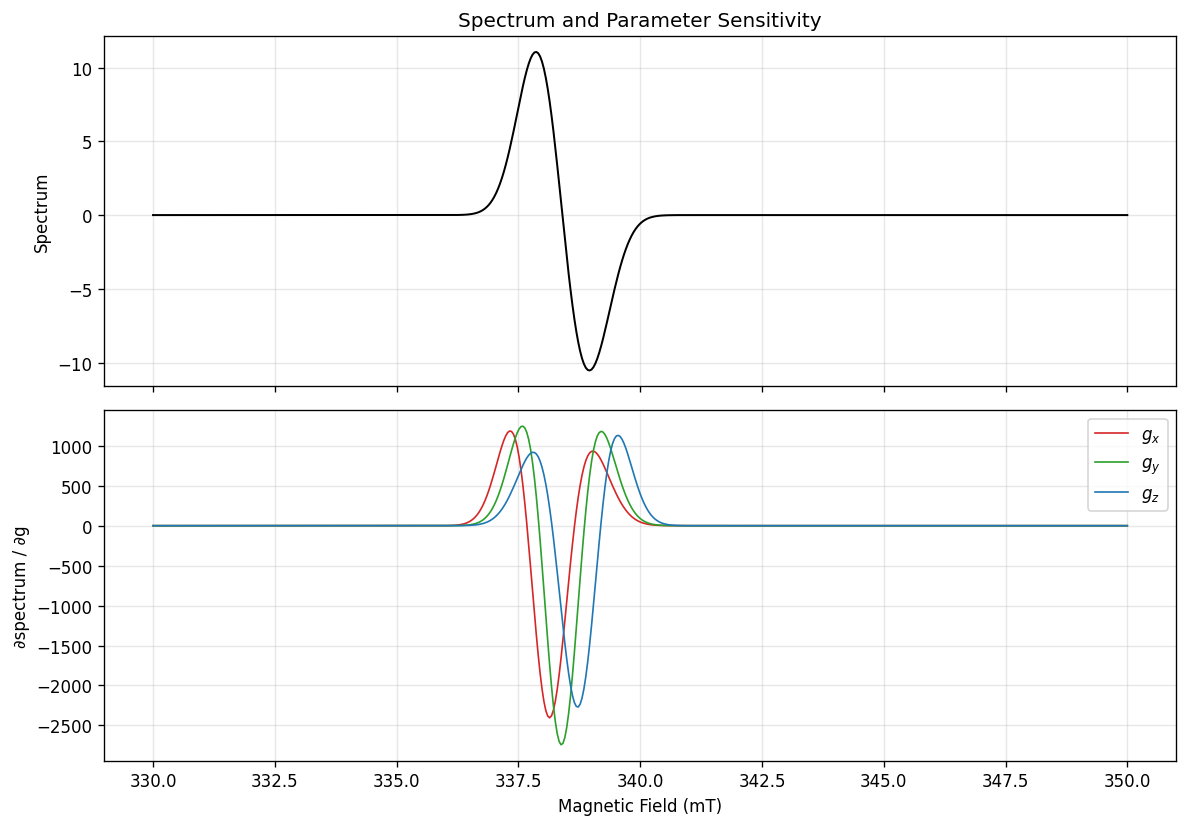

In [5]:
# Compute gradient of sum-of-squares loss w.r.t. g
loss = (spec ** 2).sum()
loss.backward()

print(f"∂L/∂g = {g.grad}")

# Visualize per-component sensitivity via finite-difference Jacobian columns
g_labels = ['$g_x$', '$g_y$', '$g_z$']
colors = ['tab:red', 'tab:green', 'tab:blue']
delta = 1e-4

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# Top: spectrum
axes[0].plot(B.detach().numpy(), spec.detach().numpy(), 'k', lw=1.2)
axes[0].set_ylabel('Spectrum')
axes[0].set_title('Spectrum and Parameter Sensitivity')

# Bottom: ∂spectrum/∂g_i via finite differences
for i in range(3):
    g_plus = g.detach().clone()
    g_plus[i] += delta
    _, spec_plus = differentiable_spectrum(
        g=g_plus, lw_mT=1.0, mwFreq_GHz=9.5,
        B_range=(330, 350), nPoints=512, Harmonic=1, GridSize=31,
    )
    g_minus = g.detach().clone()
    g_minus[i] -= delta
    _, spec_minus = differentiable_spectrum(
        g=g_minus, lw_mT=1.0, mwFreq_GHz=9.5,
        B_range=(330, 350), nPoints=512, Harmonic=1, GridSize=31,
    )
    dspc = (spec_plus - spec_minus).detach().numpy() / (2 * delta)
    axes[1].plot(B.detach().numpy(), dspc, color=colors[i], lw=1.0, label=g_labels[i])

axes[1].set_xlabel('Magnetic Field (mT)')
axes[1].set_ylabel('∂spectrum / ∂g')
axes[1].legend()
for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Gradient-Based Optimization

Since spectra are differentiable, we can use **PyTorch optimizers** directly to minimize a loss function. Here we perturb $g$-values and recover them by minimizing the squared residual against a target spectrum.

In [6]:
# Generate "target" spectrum with known g
g_true = torch.tensor([2.009, 2.006, 2.002], dtype=torch.float64)
B_target, spec_target = differentiable_spectrum(
    g=g_true, lw_mT=1.0, mwFreq_GHz=9.5,
    B_range=(330, 350), nPoints=512, Harmonic=1, GridSize=31,
)
spec_target = spec_target.detach()

# Start from perturbed g
g_opt = torch.tensor([2.005, 2.003, 2.000], dtype=torch.float64, requires_grad=True)
optimizer = torch.optim.Adam([g_opt], lr=1e-4)

losses = []
g_history = []
for step in range(500):
    optimizer.zero_grad()
    _, spec_pred = differentiable_spectrum(
        g=g_opt, lw_mT=1.0, mwFreq_GHz=9.5,
        B_range=(330, 350), nPoints=512, Harmonic=1, GridSize=31,
    )
    loss = ((spec_pred - spec_target) ** 2).sum()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    g_history.append(g_opt.detach().clone().numpy())

print(f"True g:      {g_true.numpy()}")
print(f"Recovered g: {g_opt.detach().numpy()}")
print(f"Final loss:  {losses[-1]:.6e}")

True g:      [2.009 2.006 2.002]
Recovered g: [2.00898691 2.00601399 2.00199082]
Final loss:  4.362954e-03


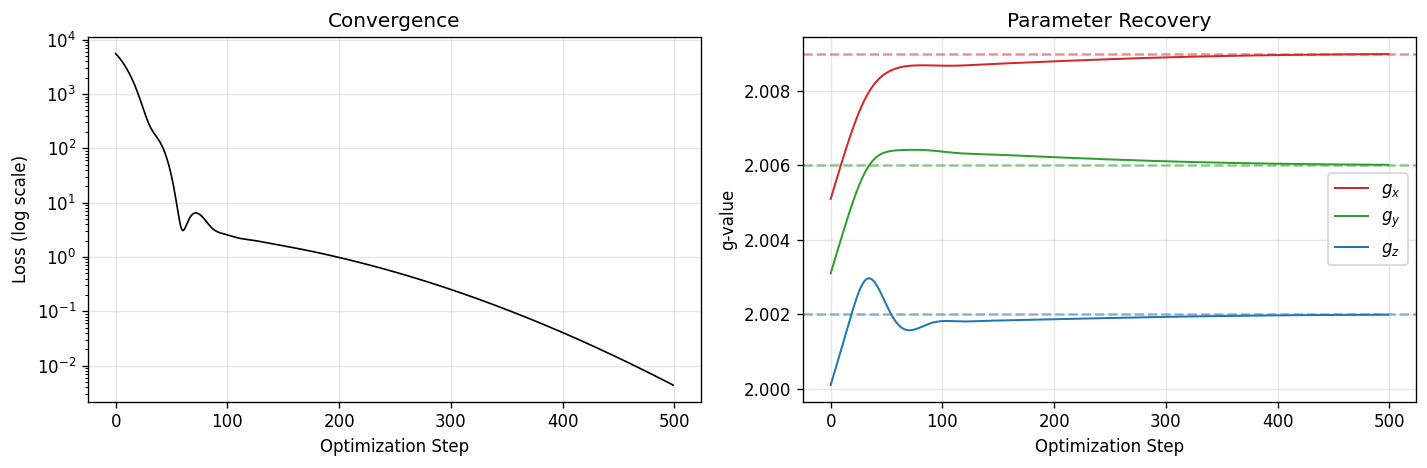

In [7]:
# Plot convergence
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss curve
axes[0].semilogy(losses, 'k', lw=1)
axes[0].set_xlabel('Optimization Step')
axes[0].set_ylabel('Loss (log scale)')
axes[0].set_title('Convergence')
axes[0].grid(True, alpha=0.3)

# g-value trajectories
g_history = np.array(g_history)
for i, (label, color) in enumerate(zip(['$g_x$', '$g_y$', '$g_z$'], ['tab:red', 'tab:green', 'tab:blue'])):
    axes[1].plot(g_history[:, i], color=color, lw=1.2, label=label)
    axes[1].axhline(g_true[i].item(), color=color, ls='--', alpha=0.5)
axes[1].set_xlabel('Optimization Step')
axes[1].set_ylabel('g-value')
axes[1].set_title('Parameter Recovery')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

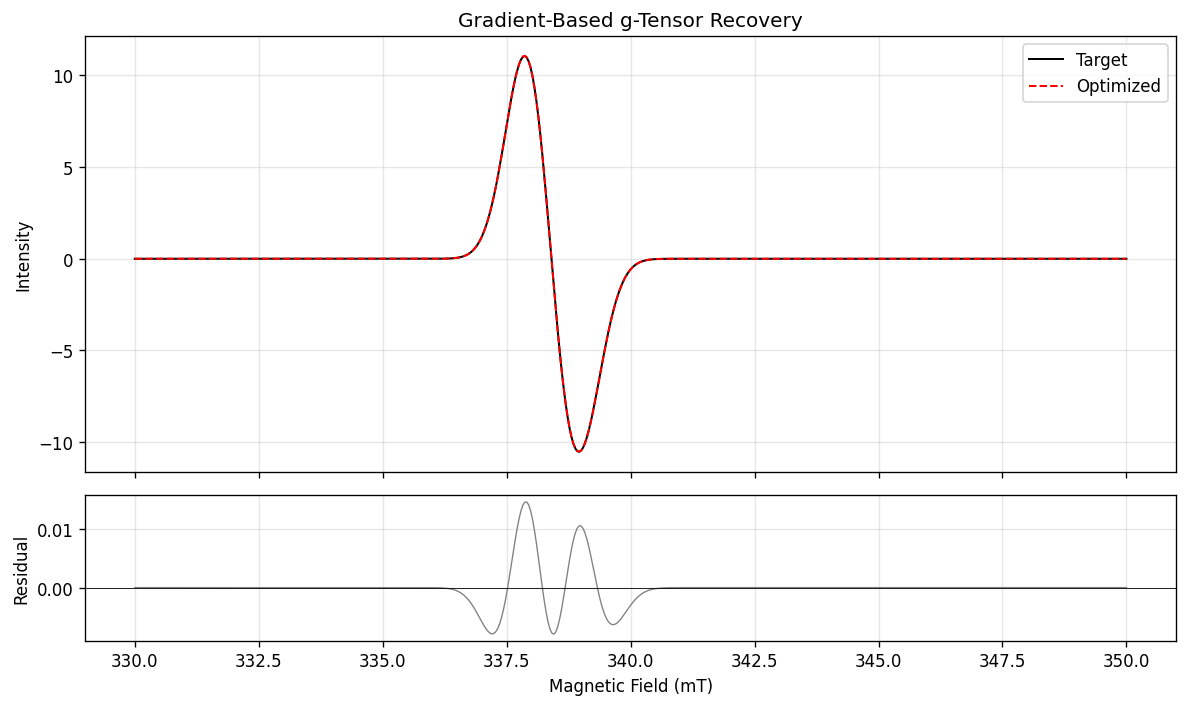

In [8]:
# Compare final fit to target
_, spec_final = differentiable_spectrum(
    g=g_opt.detach(), lw_mT=1.0, mwFreq_GHz=9.5,
    B_range=(330, 350), nPoints=512, Harmonic=1, GridSize=31,
)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True,
                          gridspec_kw={'height_ratios': [3, 1]})
axes[0].plot(B_target.numpy(), spec_target.numpy(), 'k', lw=1.2, label='Target')
axes[0].plot(B_target.numpy(), spec_final.numpy(), 'r--', lw=1.2, label='Optimized')
axes[0].set_ylabel('Intensity')
axes[0].set_title('Gradient-Based g-Tensor Recovery')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

residual = spec_final.numpy() - spec_target.numpy()
axes[1].plot(B_target.numpy(), residual, 'gray', lw=0.8)
axes[1].axhline(0, color='k', ls='-', lw=0.5)
axes[1].set_xlabel('Magnetic Field (mT)')
axes[1].set_ylabel('Residual')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

| Feature | How |
|---------|-----|
| GPU acceleration | `Options(device='cuda')` in `pepper` |
| Differentiable spectra | `differentiable_spectrum(g, ..., requires_grad=True)` |
| Gradient computation | Standard `loss.backward()` / `torch.autograd.grad()` |
| Optimization | Any PyTorch optimizer (Adam, L-BFGS, etc.) |

This enables gradient-based fitting, sensitivity analysis, and integration with neural network pipelines.